In [81]:
import pandas as pd

In [82]:
pitch_data = pd.read_csv('train_pitch_2020-05-12_2025-08-01.csv')
play_result_data = pd.read_csv('train_pitch_result_2020-05-12_2025-08-01.csv')
pitch_context = pd.read_csv('train_pitch_context_2020-05-12_2025-08-01.csv')
combined_df = pd.concat([pitch_data, play_result_data, pitch_context], axis=1)
combined_df = combined_df.loc[:, ~combined_df.columns.duplicated()].iloc[-250000:]

In [83]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class HierarchicalTransFusion(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, n_heads, 
                 pitch_type_vocab, result_vocab, info_dim):
        super().__init__()
        
        self.embedding = nn.Linear(input_dim, hidden_dim)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim, nhead=n_heads, batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        self.type_head = nn.Linear(hidden_dim, pitch_type_vocab)
        self.type_embedding = nn.Embedding(pitch_type_vocab, hidden_dim)
        
        # self.info_diffusion_head = nn.Sequential(
        #     nn.Linear(hidden_dim * 2 + info_dim + 1, hidden_dim),
        #     nn.SiLU(),
        #     nn.Linear(hidden_dim, info_dim)
        # )
        
        self.result_head = nn.Sequential(
            nn.Linear(hidden_dim * 2 + info_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, result_vocab)
        )

    def generate_causal_mask(self, sz):
        mask = torch.triu(torch.ones(sz, sz) * float('-inf'), diagonal=1)
        return mask

    def forward(self, sequence, noisy_info, t_diff, true_type=None, true_info=None):
        """
        sequence: [Batch, Seq_Len, Input_Dim]
        noisy_info: [Batch, Info_Dim] (Used for Diffusion training)
        t_diff: [Batch, 1] (Diffusion timestep)
        """
        device = sequence.device
        batch_size, seq_len, _ = sequence.shape
        
        # --- Stage 0: Context Encoding ---
        mask = self.generate_causal_mask(seq_len).to(device)
        x = self.embedding(sequence)
        h_all = self.transformer(x, mask=mask)
        h_t = h_all[:, -1, :] # Extract the hidden state for the current event
        
        # --- Stage 1: Pitch Type (Intent) ---
        type_logits = self.type_head(h_t)
        
        # --- Stage 2: Pitch Info (Execution via Diffusion) ---
        # During training, we use ground truth 'true_type'. 
        # During MCMC sampling, we'd use argmax/sampled type.
        type_ctx = self.type_embedding(true_type)
        
        # Concat context, pitch type, and the noisy sample for diffusion
        diffusion_input = torch.cat([h_t, type_ctx, noisy_info, t_diff], dim=-1)
        # pred_noise = self.info_diffusion_head(diffusion_input)
        
        # --- Stage 3: Result (Outcome) ---
        # Condition on the context, the type, AND the actual physical info
        result_input = torch.cat([h_t, type_ctx, true_info], dim=-1)
        result_logits = self.result_head(result_input)
        
        return type_logits, None, result_logits

# --- Loss Function Logic ---
def transfusion_loss(model_output, targets, weights, type_weights, result_weights):
    type_logits, pred_noise, result_logits = model_output
    target_type, target_noise, target_result = targets
    
    # 1. Discrete Cross Entropy
    loss_type = F.cross_entropy(type_logits, target_type, label_smoothing=0.1, weight=type_weights.to(type_logits.device))
    loss_result = F.cross_entropy(result_logits, target_result, label_smoothing=0.1, weight=result_weights.to(result_logits.device))
    
    # 2. Continuous Diffusion MSE
    # loss_info = F.mse_loss(pred_noise, target_noise)
    
    # 3. Weighted Total
    total_loss = (weights['type'] * loss_type + 
                #   weights['info'] * loss_info + 
                  weights['result'] * loss_result)
    
    return total_loss

In [84]:
combined_df.index = combined_df['game_id'] + '_' + combined_df['at_bat_id'].astype(str) + '_' + combined_df['pitch_id'].astype(str)
drop_cols = []
for col in combined_df.columns:
    if 'away_team' in col or 'home_team' in col:
        drop_cols.append(col)
combined_df = combined_df.drop(columns=['game_id', 'game_date', 'zone'] + drop_cols)
combined_df = pd.get_dummies(combined_df, columns=['pitch_type', 'description']).astype(float)

In [85]:
combined_df

,release_speed,plate_x,plate_z,pfx_x,pfx_z,release_spin_rate,at_bat_id,pitch_id,balls,strikes,...,description_called_strike,description_foul,description_foul_bunt,description_foul_tip,description_hit_by_pitch,description_hit_into_play,description_missed_bunt,description_pitchout,description_swinging_strike,description_swinging_strike_blocked
2021-09-17_MIL_CHC_76_3,86.5,-1.958053,3.551077,1.14,-0.30,2651.0,76.0,3.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2021-09-17_TEX_CWS_76_3,93.5,-0.602072,2.557431,-0.56,1.53,2317.0,76.0,3.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2021-09-17_SF_ATL_76_3,93.1,-0.107441,2.771308,1.60,0.90,2537.0,76.0,3.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2021-09-17_WSH_COL_76_3,87.4,1.214166,0.293932,-1.08,0.08,1205.0,76.0,3.0,1.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2021-09-17_TB_DET_76_3,78.2,-1.584849,0.977034,1.46,-0.72,2485.0,76.0,3.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-04-01_KC_TEX_99_7,94.4,0.348368,1.931371,0.09,1.28,2298.0,99.0,7.0,3.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2021-04-21_ATH_MIN_99_7,90.8,-0.085743,1.593376,-0.22,0.81,2119.0,99.0,7.0,1.0,2.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2021-04-25_LAD_SD_99_7,96.5,1.614773,2.992461,0.67,1.23,2367.0,99.0,7.0,3.0,2.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-06-09_BOS_TB_99_7,92.6,0.908912,2.014056,0.14,0.88,2256.0,99.0,7.0,3.0,2.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [86]:
# import torch
# import numpy as np
# from torch.utils.data import Dataset, DataLoader

# # ── Column definitions ──
# PITCH_TYPE_COLS = sorted([c for c in combined_df.columns if c.startswith('pitch_type_')])
# DESC_COLS       = sorted([c for c in combined_df.columns if c.startswith('description_')])
# INFO_COLS       = ['release_speed', 'plate_x', 'plate_z', 'pfx_x', 'pfx_z', 'release_spin_rate']
# CONTEXT_COLS    = [c for c in combined_df.columns
#                    if c not in PITCH_TYPE_COLS + DESC_COLS + INFO_COLS + ['at_bat_id', 'pitch_id']]

# print(f"pitch_type classes: {len(PITCH_TYPE_COLS)}")
# print(f"description classes: {len(DESC_COLS)}")
# print(f"info (continuous):   {len(INFO_COLS)}")
# print(f"context features:    {len(CONTEXT_COLS)}")

# # ── Normalise continuous info columns on training set ──
# info_mean = combined_df[INFO_COLS].mean()
# info_std  = combined_df[INFO_COLS].std().replace(0, 1)

# # Fill NaNs with 0 *before* normalising (affects ~2-3% of rows)
# combined_df[INFO_COLS] = combined_df[INFO_COLS].fillna(0)
# combined_df[INFO_COLS] = (combined_df[INFO_COLS] - info_mean) / info_std

# # ── Build per-at-bat groups (game_id is already in the index) ──
# # The index is "gameId_atBatId_pitchId", so we group on the first two parts
# combined_df['_group_key'] = combined_df.index.str.rsplit('_', n=1).str[0]
# groups = combined_df.groupby('_group_key')

# at_bat_list = []
# for _, g in groups:
#     g = g.sort_values('pitch_id')
#     at_bat_list.append(g)

# print(f"\nTotal at-bats: {len(at_bat_list):,}")
# print(f"Avg pitches/AB: {np.mean([len(g) for g in at_bat_list]):.2f}")

In [87]:
# class AtBatDataset(Dataset):
#     """
#     Each sample is one at-bat.  For an at-bat of length L we return the
#     full pitch sequence (L, input_dim) and the *last* pitch's targets:
#       - true_type  : int   (argmax of one-hot pitch_type)
#       - true_info  : (6,)  (normalised continuous pitch attributes)
#       - true_result: int   (argmax of one-hot description)
#     The sequence fed to the transformer = all L pitches (each pitch is the
#     full 103-dim feature vector).  The model predicts the last pitch's
#     type/info/result conditioned on the causal context of all L pitches.
#     """
#     def __init__(self, ab_list, context_cols, info_cols, pt_cols, desc_cols, max_seq=20):
#         self.samples = []
#         for g in ab_list:
#             L = min(len(g), max_seq)
#             g = g.iloc[:L]

#             # Sequence: all feature columns -> (L, input_dim)
#             seq = g[context_cols + info_cols + pt_cols + desc_cols].values.astype(np.float32)

#             # Targets for the *last* pitch
#             last = g.iloc[-1]
#             true_type   = int(np.argmax(last[pt_cols].values.astype(np.float32)))
#             true_info   = last[info_cols].values.astype(np.float32)
#             true_result = int(np.argmax(last[desc_cols].values.astype(np.float32)))

#             self.samples.append((seq, true_type, true_info, true_result))

#     def __len__(self):
#         return len(self.samples)

#     def __getitem__(self, idx):
#         seq, tt, ti, tr = self.samples[idx]
#         return (torch.tensor(seq), torch.tensor(tt, dtype=torch.long),
#                 torch.tensor(ti), torch.tensor(tr, dtype=torch.long))


# def collate_fn(batch):
#     """Pad variable-length sequences to max length in the batch."""
#     seqs, types, infos, results = zip(*batch)
#     max_len = max(s.shape[0] for s in seqs)
#     input_dim = seqs[0].shape[1]
#     B = len(batch)

#     padded = torch.zeros(B, max_len, input_dim)
#     for i, s in enumerate(seqs):
#         padded[i, :s.shape[0]] = s

#     return (padded,
#             torch.stack(types),
#             torch.stack(infos),
#             torch.stack(results))

# # ---- Build dataset ----
# dataset = AtBatDataset(at_bat_list, CONTEXT_COLS, INFO_COLS, PITCH_TYPE_COLS, DESC_COLS)
# print(f"Dataset size: {len(dataset):,} at-bats")

# # 90/10 train/val split
# n_val = int(0.1 * len(dataset))
# n_train = len(dataset) - n_val
# train_ds, val_ds = torch.utils.data.random_split(dataset, [n_train, n_val],
#                                                   generator=torch.Generator().manual_seed(42))
# print(f"Train: {len(train_ds):,}  Val: {len(val_ds):,}")

# # Quick shape check
# seq, tt, ti, tr = dataset[0]
# print(f"\nSample shapes:  seq={seq.shape}  type={tt}  info={ti.shape}  result={tr}")

In [88]:
# import copy, math, time

# # ---- Hyperparameters ----
# INPUT_DIM  = len(CONTEXT_COLS) + len(INFO_COLS) + len(PITCH_TYPE_COLS) + len(DESC_COLS)  # 103
# HIDDEN_DIM = 256
# NUM_LAYERS = 8
# N_HEADS    = 8
# PITCH_TYPE_VOCAB = len(PITCH_TYPE_COLS)   # 18
# RESULT_VOCAB     = len(DESC_COLS)         # 17
# INFO_DIM         = len(INFO_COLS)         # 6
# BATCH_SIZE = 64
# LR = 5e-4
# EPOCHS = 50
# T_MAX = 1000  # diffusion timesteps

# LOSS_WEIGHTS = {'type': 1.0, 'info': 5.0, 'result': 2.0}

# type_weights = torch.tensor(combined_df[PITCH_TYPE_COLS].mean().values, dtype=torch.float32)
# result_weights = torch.tensor(combined_df[DESC_COLS].mean().values, dtype=torch.float32)

# device = torch.device('cuda' if torch.cuda.is_available()
#                       else 'mps' if torch.backends.mps.is_available()
#                       else 'cpu')
# print(f"Device: {device}")

# # ---- Build model ----
# # model = HierarchicalTransFusion(
# #     input_dim=INPUT_DIM,
# #     hidden_dim=HIDDEN_DIM,
# #     num_layers=NUM_LAYERS,
# #     n_heads=N_HEADS,
# #     pitch_type_vocab=PITCH_TYPE_VOCAB,
# #     result_vocab=RESULT_VOCAB,
# #     info_dim=INFO_DIM,
# # ).to(device)

# # n_params = sum(p.numel() for p in model.parameters())
# # print(f"Model parameters: {n_params:,}")

# # ---- Dataloaders ----
# train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
#                           collate_fn=collate_fn, num_workers=0, drop_last=True)
# val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
#                           collate_fn=collate_fn, num_workers=0)

# print(f"Train batches: {len(train_loader)}  Val batches: {len(val_loader)}")

In [89]:
# # ---- Simple linear noise schedule for diffusion ----
# betas = torch.linspace(1e-4, 0.02, T_MAX, device=device)
# alphas = 1.0 - betas
# alpha_bar = torch.cumprod(alphas, dim=0)

# def q_sample(x0, t):
#     """Add noise to x0 at timestep t. Returns (noisy_x, noise)."""
#     ab = alpha_bar[t].unsqueeze(-1)          # (B, 1)
#     noise = torch.randn_like(x0)
#     noisy = torch.sqrt(ab) * x0 + torch.sqrt(1 - ab) * noise
#     return noisy, noise

# # ---- Training loop ----
# optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01, betas=(0.9, 0.95))
# # scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6)

# best_val_loss = float('inf')
# best_state = None
# history = {'train_loss': [], 'val_loss': [], 'val_type_acc': [], 'val_result_acc': []}

# for epoch in range(EPOCHS):
#     model.train()
#     t0 = time.time()
#     running = 0.0
#     n_batches = 0

#     for seq, true_type, true_info, true_result in train_loader:
#         seq        = seq.to(device)
#         true_type  = true_type.to(device)
#         true_info  = true_info.to(device)
#         true_result = true_result.to(device)

#         # Sample random diffusion timesteps and noise the continuous info
#         t = torch.randint(0, T_MAX, (seq.size(0),), device=device)
#         noisy_info, noise = q_sample(true_info, t)
#         t_norm = t.float().unsqueeze(-1) / T_MAX   # normalise to [0,1]

#         optimizer.zero_grad()
#         output = model(seq, noisy_info, t_norm, true_type=true_type, true_info=true_info)
#         targets = (true_type, noise, true_result)   # diffusion predicts noise
#         loss = transfusion_loss(output, targets, LOSS_WEIGHTS, type_weights, result_weights)
#         loss.backward()
#         torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#         optimizer.step()

#         running += loss.item()
#         n_batches += 1

#     avg_train = running / n_batches

#     # ---- Validation ----
#     model.eval()
#     val_loss_sum = 0.0
#     correct_type = correct_result = total = 0
#     n_val = 0

#     with torch.no_grad():
#         for seq, true_type, true_info, true_result in val_loader:
#             seq        = seq.to(device)
#             true_type  = true_type.to(device)
#             true_info  = true_info.to(device)
#             true_result = true_result.to(device)

#             t = torch.randint(0, T_MAX, (seq.size(0),), device=device)
#             noisy_info, noise = q_sample(true_info, t)
#             t_norm = t.float().unsqueeze(-1) / T_MAX

#             output = model(seq, noisy_info, t_norm, true_type=true_type, true_info=true_info)
#             targets = (true_type, noise, true_result)
#             loss = transfusion_loss(output, targets, LOSS_WEIGHTS, type_weights, result_weights)

#             val_loss_sum += loss.item()
#             n_val += 1

#             type_logits, _, result_logits = output
#             correct_type   += (type_logits.argmax(-1) == true_type).sum().item()
#             correct_result += (result_logits.argmax(-1) == true_result).sum().item()
#             total += true_type.size(0)

#     avg_val = val_loss_sum / max(n_val, 1)
#     type_acc   = correct_type / max(total, 1)
#     result_acc = correct_result / max(total, 1)

#     marker = ''
#     if avg_val < best_val_loss:
#         best_val_loss = avg_val
#         best_state = copy.deepcopy(model.state_dict())
#         marker = ' *'

#     history['train_loss'].append(avg_train)
#     history['val_loss'].append(avg_val)
#     history['val_type_acc'].append(type_acc)
#     history['val_result_acc'].append(result_acc)

#     elapsed = time.time() - t0
#     print(f"Epoch {epoch+1:2d}/{EPOCHS} | "
#           f"Train: {avg_train:.4f}  Val: {avg_val:.4f} | "
#           f"Type Acc: {type_acc:.2%}  Result Acc: {result_acc:.2%} | "
#           f"LR: {scheduler.get_last_lr()[0]:.6f}  {elapsed:.0f}s{marker}")
#     scheduler.step(avg_val)
# print(f"\nBest val loss: {best_val_loss:.4f}")
# model.load_state_dict(best_state)

---- 

----

In [90]:
# class SequencePredictor(nn.Module):
#     def __init__(indim, outdim):
#         super().__init__()
#         nn.MultiheadAttention()
#         nn.Transformer()
#         nn.Enc

In [101]:
DEVICE = 'cpu'
class Encoder(nn.Module):
    
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(Encoder, self).__init__()

        self.FC_input = nn.Linear(input_dim, hidden_dim)
        self.FC_input2 = nn.Linear(hidden_dim, hidden_dim)
        self.FC_mean  = nn.Linear(hidden_dim, latent_dim)
        self.FC_var   = nn.Linear (hidden_dim, latent_dim)
        
        self.LeakyReLU = nn.LeakyReLU(0.2)
        
        self.training = True
        
    def forward(self, x):
        h_       = self.LeakyReLU(self.FC_input(x))
        h_       = self.LeakyReLU(self.FC_input2(h_))
        mean     = self.FC_mean(h_)
        log_var  = self.FC_var(h_)                     # encoder produces mean and log of variance 
                                                       #             (i.e., parateters of simple tractable normal distribution "q"
        
        return mean, log_var
    
class Decoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim):
        super(Decoder, self).__init__()
        self.FC_hidden = nn.Linear(latent_dim, hidden_dim)
        self.FC_hidden2 = nn.Linear(hidden_dim, hidden_dim)
        self.FC_output = nn.Linear(hidden_dim, output_dim)
        
        self.LeakyReLU = nn.LeakyReLU(0.2)
        
    def forward(self, x):
        h     = self.LeakyReLU(self.FC_hidden(x))
        h     = self.LeakyReLU(self.FC_hidden2(h))
        
        x_hat = torch.sigmoid(self.FC_output(h))
        return x_hat
    
class Model(nn.Module):
    def __init__(self, Encoder, Decoder):
        super(Model, self).__init__()
        self.Encoder = Encoder
        self.Decoder = Decoder
        
    def reparameterization(self, mean, var):
        epsilon = torch.randn_like(var).to(DEVICE)        # sampling epsilon        
        z = mean + var*epsilon                          # reparameterization trick
        return z
        
                
    def forward(self, x):
        mean, log_var = self.Encoder(x)
        z = self.reparameterization(mean, torch.exp(0.5 * log_var)) # takes exponential function (log var -> var)
        x_hat            = self.Decoder(z)
        
        return x_hat, mean, log_var

In [110]:
encoder = Encoder(input_dim=100, hidden_dim=250, latent_dim=50)
decoder = Decoder(latent_dim=50, hidden_dim = 250, output_dim = 100)

model = Model(Encoder=encoder, Decoder=decoder).to(DEVICE)

def loss_function(x, x_hat, mean, log_var):
    reproduction_loss = nn.functional.mse_loss(x_hat, x, reduction='sum')
    KLD      = - 0.5 * torch.sum(1+ log_var - mean.pow(2) - log_var.exp())
    return reproduction_loss + KLD

optimizer = torch.optim.Adam(model.parameters(), lr = 1e-4, weight_decay=1e-8)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

In [111]:
from torch.utils.data import DataLoader, TensorDataset

combined_df = combined_df.dropna()
combined_df = (combined_df - combined_df.mean())/combined_df.std()
training_data, val_data = combined_df.iloc[:int(len(combined_df) * 0.8)], combined_df.iloc[int(len(combined_df) * 0.8):]

train_tensor = torch.tensor(training_data.values, dtype=torch.float32)
val_tensor = torch.tensor(val_data.values, dtype=torch.float32)

train_ds = TensorDataset(train_tensor)
val_ds = TensorDataset(val_tensor)

train_dataloader = DataLoader(train_ds, batch_size = 64, shuffle=True)
val_dataloader = DataLoader(val_ds, batch_size = 64, shuffle=True)

Epoch 1/100, Train Loss: 6268.830078, Val Loss: 6153.735352 | LR: 0.0001
Epoch 2/100, Train Loss: 6040.728027, Val Loss: 6103.951172 | LR: 0.0001
Epoch 3/100, Train Loss: 5977.300781, Val Loss: 6037.477051 | LR: 0.0001
Epoch 4/100, Train Loss: 5917.586914, Val Loss: 5984.700684 | LR: 0.0001
Epoch 5/100, Train Loss: 5884.786133, Val Loss: 5970.626953 | LR: 0.0001
Epoch 6/100, Train Loss: 5863.836914, Val Loss: 5964.800293 | LR: 0.0001
Epoch 7/100, Train Loss: 5844.521484, Val Loss: 5940.321289 | LR: 0.0001
Epoch 8/100, Train Loss: 5821.274902, Val Loss: 5916.250000 | LR: 0.0001
Epoch 9/100, Train Loss: 5787.306641, Val Loss: 5863.079102 | LR: 0.0001
Epoch 10/100, Train Loss: 5760.838867, Val Loss: 5838.640137 | LR: 0.0001
Epoch 11/100, Train Loss: 5740.376465, Val Loss: 5817.933594 | LR: 0.0001
Epoch 12/100, Train Loss: 5720.228516, Val Loss: 5803.921875 | LR: 0.0001
Epoch 13/100, Train Loss: 5704.336914, Val Loss: 5788.615723 | LR: 0.0001
Epoch 14/100, Train Loss: 5690.158203, Val Loss

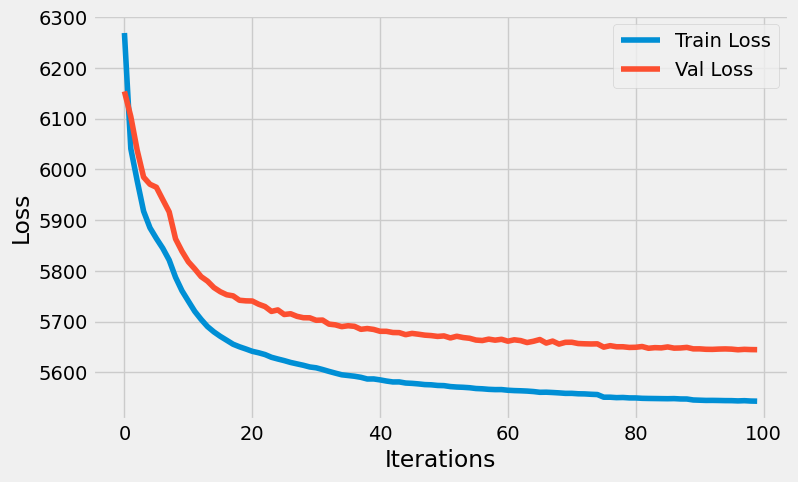

In [112]:
import matplotlib.pyplot as plt


epochs = 100
losses = []
val_losses = []
best_val = float('inf')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

for epoch in range(epochs):
    epoch_losses = []
    model.train()
    for batch in train_dataloader:
        data = batch[0]

        reconstructed, mean, logvar = model(data)
        loss = loss_function(data, reconstructed, mean, logvar)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_losses.append(loss.item())
    
    losses.append(torch.mean(torch.tensor(epoch_losses)))

    epoch_losses = []
    
    model.eval()
    with torch.no_grad():
        for batch in val_dataloader:
            data = batch[0]

            reconstructed, mean, logvar = model(data)
            loss = loss_function(data, reconstructed, mean, logvar)

            epoch_losses.append(loss.item())
    val_losses.append(torch.mean(torch.tensor(epoch_losses)))

    scheduler.step(val_losses[-1])


    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {losses[-1]:.6f}, Val Loss: {val_losses[-1]:.6f} | LR: {optimizer.param_groups[0]['lr']}")

plt.style.use('fivethirtyeight')
plt.figure(figsize=(8, 5))
plt.plot(losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd

pitch_results = pd.read_csv('train_pitch_result_2020-05-12_2025-08-01.csv')
pitches = pd.read_csv('train_pitch_2020-05-12_2025-08-01.csv')
pitches = pitches.drop(columns=['game_id', 'game_date', 'home_team', 'away_team'])
pitches = pd.get_dummies(pitches, columns=['pitch_type', 'zone'])
pitch_context = pd.read_csv('train_pitch_context_2020-05-12_2025-08-01.csv')
df = pd.concat([pitch_results, pitches, pitch_context], axis=1).dropna()
# pitch_results = pd.get_dummies(pitch_results)

In [3]:
df = df.loc[:, ~df.columns.duplicated()]

In [4]:
X, y = df.drop(columns='description'), df['description']
y = y.map({df['description'].unique()[i] : i for i in range(len(df['description'].unique()))})
X = X.drop(X.select_dtypes(include='object').columns, axis=1).astype(float)

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

# --- Data prep ---
num_classes = y.nunique()
input_dim = X.shape[1]

def label_smooth(y):
    y = y.float()
    n_classes = num_classes
    smooth = 0.1
    y = y * (1 - smooth) + smooth / n_classes
    return y

X_train, X_val, y_train, y_val = train_test_split(X.astype(float).values, y.astype(float).values, test_size=0.2, random_state=42)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t   = torch.tensor(X_val, dtype=torch.float32)
y_val_t   = torch.tensor(y_val, dtype=torch.long)

# y_train_t = label_smooth(y_train_t)
# y_val_t = label_smooth(y_val_t)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=512, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t),     batch_size=512)

# --- MLP ---
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.BatchNorm1d(input_dim),
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(0.5),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(0.5),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(0.5),
            nn.Linear(hidden_dim, num_classes),
            nn.LogSoftmax(dim=1)
            # nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)  # raw logits; softmax handled by CE loss
    
    

# device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mlp = MLP(input_dim, 1024, num_classes).to(device)

def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

mlp.apply(init_weights)

class_weights = torch.tensor(y.value_counts(normalize=True).sort_index().values, dtype=torch.float32)

criterion = nn.NLLLoss()
optimizer = torch.optim.Adam(mlp.parameters(), lr=5e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

# --- Training ---
train_losses, val_losses = [], []
best_val_loss = float('inf')
for epoch in range(30):
    mlp.train()
    total_loss, correct, total = 0.0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = mlp(xb)
        loss = criterion(logits, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
        correct += (logits.argmax(1) == yb).sum().item()
        total += xb.size(0)

    mlp.eval()
    val_correct, val_total, val_loss = 0, 0, 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = mlp(xb)
            val_loss += criterion(logits, yb).item() * xb.size(0)
            val_correct += (logits.argmax(1) == yb).sum().item()
            val_total += xb.size(0)

    train_acc = correct / total
    val_acc = val_correct / val_total
    scheduler.step(val_loss / val_total)

    train_losses.append(total_loss / total)
    val_losses.append(val_loss / val_total)

    marker = ""
    if val_loss / val_total < best_val_loss:
        best_val_loss = val_loss / val_total
        best_state = mlp.state_dict()
        marker = " *"

    print(f"Epoch {epoch+1:2d} | Train Loss {total_loss/total:.4f}  Acc {train_acc:.2%} | "
          f"Val Loss {val_loss/val_total:.4f}  Acc {val_acc:.2%} | LR: {scheduler._last_lr[0]:.6f}{marker}")

print(f"\nBest val loss: {best_val_loss/val_total:.4f}")
mlp.load_state_dict(best_state)

In [ ]:
import matplotlib.pyplot as plt

plt.style.use('fivethirtyeight')
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

NameError: name 'plt' is not defined

In [ ]:
torch.set_printoptions(precision=4, sci_mode=False)

mlp.eval()
with torch.no_grad():
    val_preds = mlp(X_val_t.to(device))

In [ ]:
val_preds.mean(dim=0)

In [ ]:
from pathlib import Path

cache_dir = Path("./baseball_cache")

# DO NOT delete statcast.parquet — keep the raw data
keep = {"statcast.parquet", "win_pct_lookup.pkl"}

for f in cache_dir.iterdir():
    # if f.name not in keep and f.suffix in {".pkl", ".parquet"}:
    f.unlink()
    print(f"Deleted {f.name}")

Deleted batter_scaler.pkl
Deleted batter_stats_statcast.parquet
Deleted encoders.pkl
Deleted pitcher_scaler.pkl
Deleted pitcher_stats_statcast.parquet
Deleted pitch_scaler.pkl
